# 7.5.2 粒子传播、退化与重采样

## 学习目标与先修知识

实现自助粒子滤波（bootstrap particle filter），比较ESS、样本贫化及固定预算下的重复误差。

先修：7.5.1的重要性权重和7.4的非线性动态。 [本篇学习次序](../README.md)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

当系统不断演化，昨天合理的样本今天可能几乎没有权重。怎样传播、吸收新观测（observation）并重新分配计算预算，又不把复制大量同一粒子误当作信息增长？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]

## 初步实验

In [2]:
w=np.array([.5,.5,0.,0.]);print('四粒子的ESS=',1/(w@w),'严格ESS<N/2时是否触发=',1/(w@w)<len(w)/2)

四粒子的ESS= 2.0 严格ESS<N/2时是否触发= False


## 模型假设

自助粒子滤波以状态（state）转移为提议。每个粒子使用独立过程增量，观测序列与其他方法相同。重采样（resampling）阈值为ESS<N/2；重采样后权重重置1/N。用于可重复判题时全部随机输入（input）显式给定；这里性能实验固定主种子并重复20次。

## 数学解释与推导

一般序贯重要性权重为
$$a_t^{(i)}=w_{t-1}^{(i)}\frac{p(y_t\mid x_t^{(i)})p(x_t^{(i)}\mid x_{t-1}^{(i)})}{q(x_t^{(i)}\mid x_{t-1}^{(i)},y_t)}.$$
自助法选择q等于状态转移，故只需已有权重乘当前似然（likelihood）；转移作用已经进入传播。

系统性重采样（systematic resampling）取一个 $u\in[0,1)$，使用位置 $(u+i)/N$，选择累计权重严格大于位置的最小下标。复制祖先后所有权重变为1/N，ESS变为N，但不同祖先数量可能很少；这叫样本贫化（sample impoverishment）。观测加权前后要分别保存统计量（statistic），不能用重采样后随机均值替代有权重均值而不说明。

## 核心实现

下面按推导写出计算步骤；函数的输入只包含模型（model）与当时可用的信息。

In [3]:
def particle_update(particles, weights, log_likelihoods, offset):
    scores = np.array([(-np.inf if w == 0 or value is None else math.log(w) + value)
                       for w, value in zip(weights, log_likelihoods)])
    if not np.isfinite(scores).any():
        return dict(status='impossible', weights=[], ess=0., indices=[], particles=[])
    normalized = np.exp(scores - scores.max())
    normalized /= normalized.sum()
    positions = (offset + np.arange(len(particles))) / len(particles)
    cumulative = np.cumsum(normalized); cumulative[-1] = 1.
    indices = np.minimum(np.searchsorted(cumulative, positions, side='right'), len(particles) - 1)
    return dict(status='ok', weights=normalized.tolist(), ess=float(1 / np.sum(normalized ** 2)),
                indices=indices.tolist(), particles=np.array(particles)[indices].tolist())


def saturating_step(state, step=.25, rate=.6, saturation_scale=1.0):
    """state和saturation_scale同为U；step*rate无量纲。"""
    return state - step * rate * state / (1 + np.abs(state) / saturation_scale)


def bootstrap_filter(initial_mean, initial_variance, process_variance, measurement_variance, observations, count, seed, threshold=.5):
    rng = np.random.default_rng(seed)
    particles = rng.normal(initial_mean, math.sqrt(initial_variance), count)
    weights = np.ones(count) / count
    means, variances, effective, unique = [], [], [], []
    for t, observed in enumerate(observations):
        if t:
            particles = saturating_step(particles) + rng.normal(0, math.sqrt(process_variance), count)
        log_likelihood = np.zeros(count) if observed is None else -.5 * (observed - particles ** 2) ** 2 / measurement_variance
        updated = particle_update(particles, weights, log_likelihood, float(rng.random()))
        if updated['status'] != 'ok':
            raise ValueError('全部粒子权重为零')
        weights = np.array(updated['weights'])
        mean = float(weights @ particles)
        means.append(mean); variances.append(float(weights @ (particles - mean) ** 2)); effective.append(updated['ess'])
        if updated['ess'] < threshold * count:
            indices = updated['indices']; particles = particles[indices]; weights = np.ones(count) / count
            unique.append(len(set(indices)))
        else:
            unique.append(count)
    return dict(means=means, variances=variances, ess=effective, distinct_ancestors=unique)


def grid_filter(initial_mean, initial_variance, process_variance, measurement_variance, observations, count=801, limit=6.):
    grid = np.linspace(-limit, limit, count)
    spacing = grid[1] - grid[0]
    quadrature = np.ones(count) * spacing; quadrature[[0, -1]] *= .5
    density = np.exp(-.5 * (grid - initial_mean) ** 2 / initial_variance)
    density /= quadrature @ density
    kernel = np.exp(-.5 * (grid[:, None] - saturating_step(grid)[None, :]) ** 2 / process_variance) / math.sqrt(2 * math.pi * process_variance)
    means, variances = [], []
    for t, observed in enumerate(observations):
        if t:
            density = kernel @ (density * quadrature)
        if observed is not None:
            log_likelihood = -.5 * (observed - grid ** 2) ** 2 / measurement_variance
            density *= np.exp(log_likelihood - log_likelihood.max())
        density /= quadrature @ density
        mean = float(quadrature @ (density * grid))
        means.append(mean); variances.append(float(quadrature @ (density * (grid - mean) ** 2)))
    return dict(grid=grid, density=density, means=means, variances=variances)

## 对照实验

| 粒子数 | 20次粒子步数预算 | 终点均值相对网格RMSE/U | 终点误差标准差/U |
| --- | --- | --- | --- |
| 100 | 24000 | 0.0230493 | 0.023584 |
| 500 | 120000 | 0.00582739 | 0.00595802 |

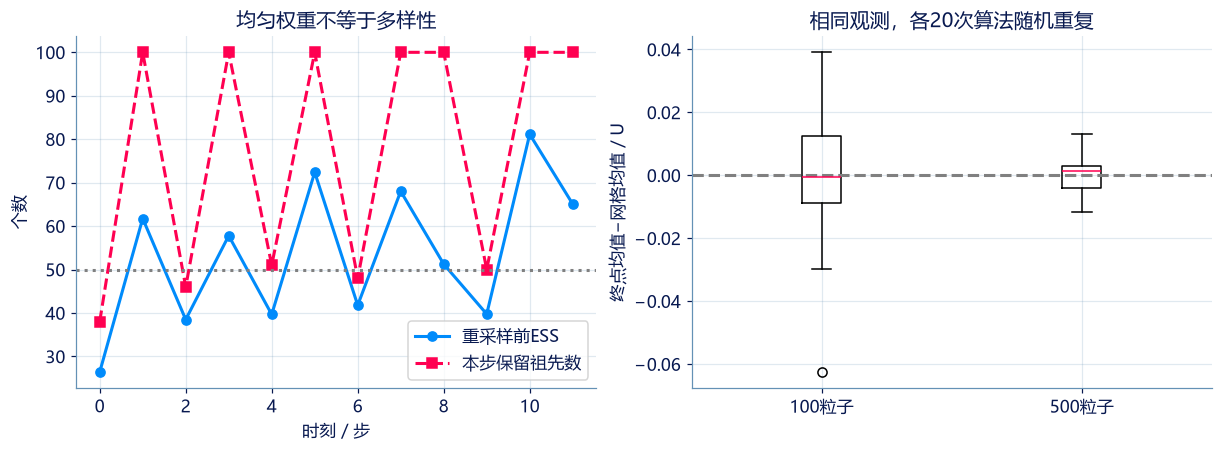

In [4]:
observed=[3.5,3.,2.8,2.1,2.,1.7,1.9,1.1,1.2,.9,.8,.6]
reference=grid_filter(1.8,.2,.04,.15,observed,count=801)
rows=[];distributions=[]
for N in [100,500]:
    errors=[]
    for repeat in range(20):
        run=bootstrap_filter(1.8,.2,.04,.15,observed,N,7500+repeat)
        errors.append(run['means'][-1]-reference['means'][-1])
    distributions.append(errors);rows.append([N,N*len(observed)*20,float(np.sqrt(np.mean(np.array(errors)**2))),float(np.std(errors,ddof=1))])
display(Markdown(show_table(['粒子数','20次粒子步数预算','终点均值相对网格RMSE/U','终点误差标准差/U'],rows)))
run=bootstrap_filter(1.8,.2,.04,.15,observed,100,7500)
fig,axes=plt.subplots(1,2,figsize=(11,4));axes[0].plot(run['ess'],'o-',label='重采样前ESS');axes[0].plot(run['distinct_ancestors'],'s--',label='本步保留祖先数');axes[0].axhline(50,color='gray',ls=':');axes[0].set(xlabel='时刻 / 步',ylabel='个数',title='均匀权重不等于多样性');axes[0].legend()
axes[1].boxplot(distributions,tick_labels=['100粒子','500粒子']);axes[1].axhline(0,color='gray',ls='--');axes[1].set(ylabel='终点均值−网格均值 / U',title='相同观测，各20次算法随机重复');plt.show()

### 独立核验与边界

In [5]:
test=particle_update([-1,0,1],[1/3]*3,[0,math.log(.5),0],.5)
np.testing.assert_allclose(test['weights'],[.4,.2,.4]);np.testing.assert_allclose(test['ess'],25/9);assert test['indices']==[0,1,2]
boundary=particle_update([0,1,2,3],[.25]*4,[0]*4,0)
assert boundary['indices']==[0,1,2,3]
repeat=bootstrap_filter(1.8,.2,.04,.15,observed,100,7500)
np.testing.assert_allclose(run['means'],repeat['means'])
print('手算权重、CDF边界和固定种子复现通过。重复结论不用于单次随机判分。')

手算权重、CDF边界和固定种子复现通过。重复结论不用于单次随机判分。


## 结果解释

箱线图比较相同观测下、不同粒子抽样得到的估计，展示粒子近似本身的波动。增大粒子数通常降低Monte Carlo误差，但预算也增加；失配模型、错误提议支持或连续祖先丢失仍可能主导结果。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：观测加权与系统性重采样

粒子已完成动态传播。用当前观测（observation）的对数似然（likelihood）更新已有权重，再按固定起点进行一次系统性重采样（systematic resampling）；题目不调用随机数。

**函数与代码模板**

```python
def solve(
    particles: list[float],
    weights: list[float],
    log_likelihoods: list[float | None],
    offset: float,
) -> tuple[list[float], float, list[int], list[float], str]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `particles` | `list[float]` | 已传播到当前时刻的状态（state）样本。 | U |
| `weights` | `list[float]` | 上一步归一化权重。 | 概率 |
| `log_likelihoods` | <code>list[float &#124; None]</code> | 当前观测的对数似然；None 表示零似然。 | 无量纲 |
| `offset` | `float` | 系统性重采样的单位起点 u，0≤u<1。 | 无量纲 |

**返回值**

按以下顺序返回元组：(normalized, ess, indices, resampled, status)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `normalized` | `list[float]` | 观测加权后的权重，重采样（resampling）前。 | 概率 |
| `ess` | `float` | 1/sum(w²)。 | 个 |
| `indices` | `list[int]` | 系统性重采样选中的祖先下标，从 0 开始。 | 无量纲 |
| `resampled` | `list[float]` | 按祖先下标取得的粒子。 | U |
| `status` | `str` | ok 或 impossible。 | 无量纲 |

**计算规则**

先稳定归一化 log(weights)+log_likelihoods。ESS=1/sum(w²)。N个采样（sampling）位置为(offset+i)/N，选择累积权重严格大于该位置的最小下标；恰好相等时进入下一段。零权重或None似然不贡献质量。全部无质量返回([],0,[],[],"impossible")。

**约束与边界**

- 粒子数1—100，各列表等长；weights≥0且和为1；0≤offset<1。
- 非None对数值有限，绝对值≤10000；状态绝对值≤100。
- 返回的normalized是重采样前权重，重采样后各粒子权重另重置为1/N。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| particles | 已传播到当前时刻的状态（state）样本。 | [-1.0, 0.0, 1.0] | U |
| weights | 上一步归一化权重。 | [0.3333333333333333, 0.3333333333333333, 0.3333333333333333] | 概率 |
| log_likelihoods | 当前观测的对数似然；None 表示零似然。 | [0.0, -0.6931471805599453, 0.0] | 无量纲 |
| offset | 系统性重采样的单位起点 u，0≤u<1。 | 0.5 | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
particles = [-1.0, 0.0, 1.0]
weights = [0.3333333333333333,
           0.3333333333333333,
           0.3333333333333333]
log_likelihoods = [0.0, -0.6931471805599453, 0.0]
offset = 0.5

result = solve(particles, weights, log_likelihoods, offset)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| normalized | 观测加权后的权重，重采样（resampling）前。 | [0.4, 0.20000000000000004, 0.4] | 概率 |
| ess | 1/sum(w²)。 | ≈ 2.777778 | 个 |
| indices | 系统性重采样选中的祖先下标，从 0 开始。 | [0, 1, 2] | 无量纲 |
| resampled | 按祖先下标取得的粒子。 | [-1.0, 0.0, 1.0] | U |
| status | ok 或 impossible。 | ok | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.4, 0.20000000000000004, 0.4],
                   2.7777777777777772,
                   [0, 1, 2],
                   [-1.0, 0.0, 1.0],
                   'ok')
```

**样例解释**

样例权重[0.4,0.2,0.4]，ESS=25/9；位置1/6、1/2、5/6选中祖先[0,1,2]。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：观测加权与系统性重采样](http://127.0.0.1:8000/chapters/07-05-%E7%B2%92%E5%AD%90%E6%BB%A4%E6%B3%A2/practice/?question=p07-particle-resampling)

### 第 2 题 · 单项选择题：有效样本量与阈值

权重[0.5,0.5,0,0]，规则为ESS<N/2才重采样（resampling）。哪项正确？

- **A.** ESS=2，不触发严格小于条件。
- **B.** ESS=4，所有粒子都有效。
- **C.** ESS=0.5。
- **D.** ESS=2，必触发小于条件。

[作答：有效样本量与阈值](http://127.0.0.1:8000/chapters/07-05-%E7%B2%92%E5%AD%90%E6%BB%A4%E6%B3%A2/practice/?question=p07-ess-threshold)

### 第 3 题 · 多项选择题：权重均匀还会贫化吗

重采样（resampling）后100个粒子的权重都为0.01，但只有3个不同祖先。哪些正确？

- **A.** ESS=100。
- **B.** 权重均匀不代表样本多样。
- **C.** 这证明后验（posterior）精确。
- **D.** 重复祖先在过程噪声（process noise）不足时可能持续。

[作答：权重均匀还会贫化吗](http://127.0.0.1:8000/chapters/07-05-%E7%B2%92%E5%AD%90%E6%BB%A4%E6%B3%A2/practice/?question=p07-ancestry-poverty)

### 第 4 题 · 单项选择题：自助滤波中为何只乘似然

自助粒子滤波（bootstrap particle filter）用状态（state）转移分布（distribution）作提议。哪项解释正确？

- **A.** 转移密度从来不影响结果。
- **B.** 一般重要性比中的转移与提议相消，传播已使用转移。
- **C.** 无论用何种提议都只乘似然（likelihood）。
- **D.** 上一步非均匀权重必须忽略。

[作答：自助滤波中为何只乘似然](http://127.0.0.1:8000/chapters/07-05-%E7%B2%92%E5%AD%90%E6%BB%A4%E6%B3%A2/practice/?question=p07-bootstrap-proposal)

### 第 5 题 · 多项选择题：有限预算怎样比较

比较N=100和N=500的粒子滤波（particle filtering，PF）。哪些做法合理？

- **A.** 共享同一观测（observation）序列，分别重复独立粒子随机数。
- **B.** 报告误差均值、波动和粒子步数预算。
- **C.** 只挑每个方法表现最好的一次。
- **D.** 据一次精确命中宣称普遍优于KF。

[作答：有限预算怎样比较](http://127.0.0.1:8000/chapters/07-05-%E7%B2%92%E5%AD%90%E6%BB%A4%E6%B3%A2/practice/?question=p07-particle-comparison)

### 延伸阅读

R26，第11章粒子滤波及重采样。 [Särkkä 与 Svensson，《Bayesian Filtering and Smoothing》第二版，2023](https://users.aalto.fi/~ssarkka/pub/bfs_book_2023_online.pdf)。本节公式、实现和核验可独立阅读；参考资料用于进一步学习。

[概念探索与交互](http://127.0.0.1:8000/chapters/07-05-粒子滤波/explore/) · [本篇目录](../README.md)